In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load dataset

In [4]:
orig_df = pd.read_csv("bike_day.csv")
orig_df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [5]:
df = orig_df.drop(["instant", "dteday"], axis=1)
df = df.copy()
orig_X = df.drop("cnt", axis=1)
X = orig_X.copy()

### Scaling

In [6]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

## Performance Evaluation

In [7]:
def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def compute_smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_rmsle(y_true, y_pred, neg_mask=0):
    # Root Mean Squared Log Error
    # RMSLE is good for right-skewed data
    # Note: log1p(x) = log(1+x), and the log parameter must be positive. 
    # Therefore, x >= -1. Otherwise, log1p(1+x) encounters an invalid value.
        
    if neg_mask == 1:
        mask = (y_true >= 0) & (y_pred >= 0)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
    
    np_y_true, np_y_pred = np.array(y_true), np.array(y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error

    return rmsle

### Experiments: Models

In [8]:
# Train and test model
# Remove high-correlated variables with y (so the model does not perfectly predict responses.)
selected_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday','workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X_base = orig_X[selected_vars]
y_base = df["cnt"]

# Train/Test Split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

### Linear Regression

In [9]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr = {}
performance_arr['Linear'] = [rmse, mae, r2, mape]

RMSE:  831.2851545662686
MAE:  617.3930656443376
MAPE:  149.38139416336597
R2:  0.8276670090367212
RMSLE:  0.49070337371466827


In [10]:
model.coef_

array([  524.72253637,  2023.99754659,   -38.44465798,  -391.55076626,
          72.93700256,   160.80489213,  -632.8562835 ,  2097.24783578,
        3488.04217936,  -865.43941913, -2080.54039519])

### Regularized Regression

#### Ridge Regression

In [11]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_alpha = 1.0   # alpha = λ

# Penalties in regularized regression are aadded to based on how large coefficients are.
# Thus, for regularized regression, scaling is needed.  
X_train, X_test = scale_standard(X_train, X_test)

from sklearn.linear_model import Ridge 
model = Ridge(alpha=selected_alpha)  
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['Ridge'] = [rmse, mae, r2, mape]

RMSE:  831.3294310662534
MAE:  617.5859194409855
MAPE:  149.2724113378202
R2:  0.8276486507036387
RMSLE:  0.49058774779950115


In [12]:
model.coef_

array([ 574.48636555, 1009.59487528, -127.92275752,  -62.15694739,
        147.23567942,   75.4907963 , -347.28004087,  394.32948415,
        549.28898721, -123.18337149, -161.2603872 ])

#### Lasso Regression

In [13]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_alpha = 0.1   # alpha = λ

# Penalties in regularized regression are aadded to based on how large coefficients are.
# Thus, for regularized regression, scaling is needed.  
X_train, X_test = scale_standard(X_train, X_test)

from sklearn.linear_model import Lasso
model = Lasso(alpha=selected_alpha)
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['Lasso'] = [rmse, mae, r2, mape]

RMSE:  831.3098119842717
MAE:  617.4392627505468
MAPE:  149.36761607773204
R2:  0.8276567854700153
RMSLE:  0.4907018130849264


In [14]:
model.coef_

array([ 577.93520439, 1011.29767724, -131.08167277,  -61.9266028 ,
        147.53853317,   75.54712445, -347.83628371,  385.69843176,
        558.16399367, -122.81145119, -160.93917308])

#### Elastic Net Regression

In [15]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_alpha = 0.1   # alpha = λ
selected_l1_ratio=0.5  # l1_ratio=0.5 → 50% L1, 50% L2

# Penalties in regularized regression are aadded to based on how large coefficients are.
# Thus, for regularized regression, scaling is needed.  
X_train, X_test = scale_standard(X_train, X_test)

from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=selected_alpha, l1_ratio=selected_l1_ratio)  
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['Elastic net'] = [rmse, mae, r2, mape]

RMSE:  837.2579823847997
MAE:  629.4080368164974
MAPE:  148.44264398363123
R2:  0.825181669032309
RMSLE:  0.49003610575457285


### KNN Regression

In [16]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_k = 5

# knn regression depends on distance method.
# thus, to compute fair distance, scaling is needed.  
X_train, X_test = scale_standard(X_train, X_test)

from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=selected_k)
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['KNN'] = [rmse, mae, r2, mape]

RMSE:  824.1280981600316
MAE:  571.8231292517007
MAPE:  138.48232633513024
R2:  0.8306216808132785
RMSLE:  0.4938199261922985


### Tree-based Regression

#### Decision Tree Regression

In [17]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['Decision Tree'] = [rmse, mae, r2, mape]

RMSE:  940.9354333831404
MAE:  661.2721088435375
MAPE:  179.75286380127844
R2:  0.7792056160060792
RMSLE:  0.5605621931591005


#### Random Forest Regression

In [18]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_n_trees = 100      # Default = 100 = number of decision trees

# For more info, go to: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor(n_estimators=selected_n_trees)
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['Random Forest'] = [rmse, mae, r2, mape]

RMSE:  687.7860409377639
MAE:  435.30938775510214
MAPE:  148.00865241573712
R2:  0.8820290462252063
RMSLE:  0.47905139541386355


### Support Vector Regression

In [19]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_kernel = 'rbf'         # Default = 'rbf'
selected_C = 1                  # Default = 1
selected_epsilon = 0.1          # Default = 0.1

from sklearn.svm import SVR
# For more info, go to: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
model = SVR(kernel=selected_kernel, C=selected_C, epsilon=selected_epsilon)  # RBF kernel, adjust C and epsilon
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['SVR'] = [rmse, mae, r2, mape]

RMSE:  2007.4938384481623
MAE:  1700.0072426154488
MAPE:  202.9639976845082
R2:  -0.005024891349365346
RMSLE:  0.7136596460188296


### Multiple-Layered Perceptron Regression

In [20]:
X_train, y_train = X_train_base.copy(), y_train_base.copy()
X_test, y_test = X_test_base.copy(), y_test_base.copy()

######################################
# Construct a model
selected_layers = (10,5)         # Default = (100,)
selected_activate = 'relu'       # Default = 'relu', Options: {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}
selected_max_iter = 10000        # Default = 200

# to find weights in mlp system, data values are important
# thus, to obtain mlp model, scaling is needed.  
X_train, X_test = scale_standard(X_train, X_test)

from sklearn.neural_network import MLPRegressor
# For more info, go to: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
#model = MLPRegressor()
model = MLPRegressor(hidden_layer_sizes=selected_layers, activation=selected_activate, max_iter=selected_max_iter)
model.fit(X_train, y_train)
######################################

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

performance_arr['MLP'] = [rmse, mae, r2, mape]

RMSE:  740.9828181232903
MAE:  522.1981092374807
MAPE:  133.37349863965284
R2:  0.863074400383984
RMSLE:  0.4743205786933346


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Performance Comparison

In [21]:
performance_arr

{'Linear': [np.float64(831.2851545662686),
  617.3930656443376,
  0.8276670090367212,
  np.float64(149.38139416336597)],
 'Ridge': [np.float64(831.3294310662534),
  617.5859194409855,
  0.8276486507036387,
  np.float64(149.2724113378202)],
 'Lasso': [np.float64(831.3098119842717),
  617.4392627505468,
  0.8276567854700153,
  np.float64(149.36761607773204)],
 'Elastic net': [np.float64(837.2579823847997),
  629.4080368164974,
  0.825181669032309,
  np.float64(148.44264398363123)],
 'KNN': [np.float64(824.1280981600316),
  571.8231292517007,
  0.8306216808132785,
  np.float64(138.48232633513024)],
 'Decision Tree': [np.float64(940.9354333831404),
  661.2721088435375,
  0.7792056160060792,
  np.float64(179.75286380127844)],
 'Random Forest': [np.float64(687.7860409377639),
  435.30938775510214,
  0.8820290462252063,
  np.float64(148.00865241573712)],
 'SVR': [np.float64(2007.4938384481623),
  1700.0072426154488,
  -0.005024891349365346,
  np.float64(202.9639976845082)],
 'MLP': [np.float6

In [22]:
metrics = ['MSE', 'RMSE', 'R2', 'MAE']
colors = {'MSE':'red', 'RMSE':'orange', 'R2':'blue', 'MAE':'purple'}

# Convert to DataFrame for easier plotting
df = pd.DataFrame(performance_arr, index=metrics)
df

,Linear,Ridge,Lasso,Elastic net,KNN,Decision Tree,Random Forest,SVR,MLP
MSE,831.285155,831.329431,831.309812,837.257982,824.128098,940.935433,687.786041,2007.493838,740.982818
RMSE,617.393066,617.585919,617.439263,629.408037,571.823129,661.272109,435.309388,1700.007243,522.198109
R2,0.827667,0.827649,0.827657,0.825182,0.830622,0.779206,0.882029,-0.005025,0.863074
MAE,149.381394,149.272411,149.367616,148.442644,138.482326,179.752864,148.008652,202.963998,133.373499


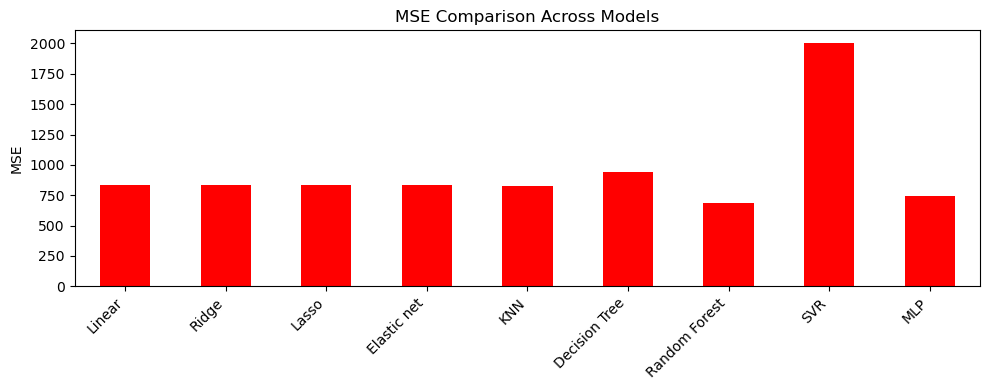

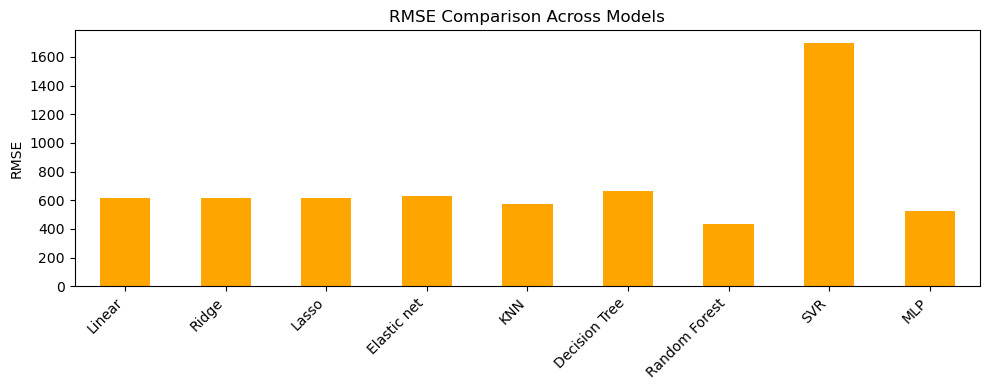

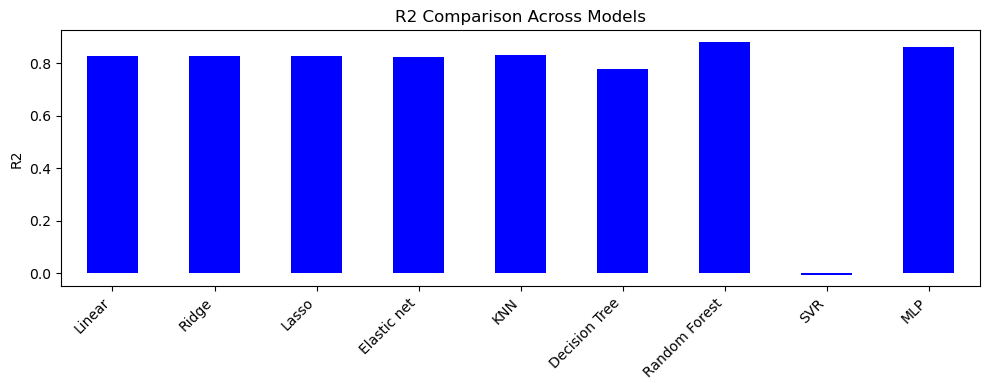

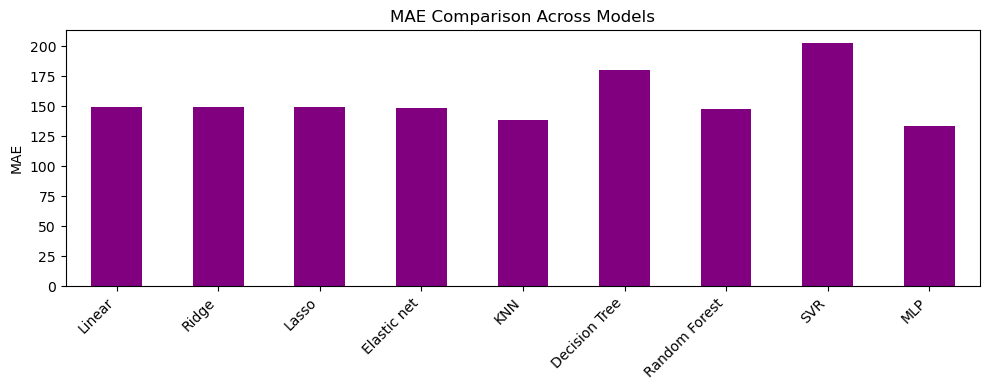

In [23]:
for metric in metrics:
    plt.figure(figsize=(10,4))
    df.loc[metric].plot(kind='bar',color=colors[metric])
    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()